In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [24]:
from lib.bck001.engine import *
from lib.rl012.sandbox import empyrical_metrics

In [3]:
method = 'ricso2'
instruments= 'rbb'
task_id = '113001'
period = '5'
category = 'test'

composite_method='equal_weight'
composite_id='7'
singal_method='rollrank2_signal'
signal_id='1002'
model_id='2018806311332385'
backtest_id = '1013836755991964'

#### 加载经过交易规则的信号数据
- 1. 模型只生成开仓信号，需要创建对应的平仓信号
- 2. 对信号进行手数，换手等处理

In [14]:
base_path1 = os.path.join(base_path, method, instruments, 'temp', 'model',
                              str(task_id), str(period), 'rl')
dirs1 = os.path.join(base_path1, "signal", "final", composite_method,
                         model_id)
filename = os.path.join(os.path.join(dirs1, "data"),
                            "event_{0}.feather".format('test'))
event_data = pd.read_feather(filename)
event_data = event_data[[
        'trade_time', 'code', 'direction', 'numbers', 'signal_type'
    ]].copy()

event_data = event_data[event_data['signal_type'].isin(['open',
                                                            'close'])].copy()
    
event_data.head()

,trade_time,code,direction,numbers,signal_type
0,2024-04-18 21:29:00,RB,-1,1,open
1,2024-04-18 21:33:00,RB,1,1,open
2,2024-04-18 21:34:00,RB,1,1,close
4,2024-04-18 21:41:00,RB,-1,1,open
5,2024-04-18 21:43:00,RB,-1,1,close


#### 加载对应的行情数据

In [15]:
trading_sessions = (("21:00", "23:00"), ("09:00", "10:15"),
                        ("10:30", "11:30"), ("13:30", "15:00"))
min_time = event_data['trade_time'].min()
max_time = event_data['trade_time'].max()
market_data = load_market_data(instruments=instruments,
                                   begin_time=min_time,
                                   end_time=max_time,
                                   trading_sessions=trading_sessions)

In [17]:
market_data.head()

,trade_time,code,symbol,open,high,low,close,volume,value,openint,vwap,chg
0,2024-04-17 21:00:00,RB,rb2410,3690.0,3692.0,3686.0,3688.0,48015.0,1.771099e+09,1822252.0,3688.637738,NaN
1,2024-04-17 21:01:00,RB,rb2410,3688.0,3688.0,3682.0,3684.0,24574.0,9.054462e+08,1821348.0,3684.569993,-0.001085
2,2024-04-17 21:02:00,RB,rb2410,3684.0,3684.0,3680.0,3680.0,14384.0,5.297288e+08,1821855.0,3682.764252,-0.001086
3,2024-04-17 21:03:00,RB,rb2410,3681.0,3683.0,3679.0,3683.0,11097.0,4.084625e+08,1824337.0,3680.837073,0.000815
4,2024-04-17 21:04:00,RB,rb2410,3683.0,3683.0,3678.0,3681.0,12216.0,4.495141e+08,1825154.0,3679.716192,-0.000543


#### 时间格式处理，符合回测要求

In [19]:
event_data['trade_time'] = pd.to_datetime(event_data['trade_time'])
event_data['date'] = event_data['trade_time'].dt.normalize()
event_data['min_time'] = event_data['trade_time'].dt.strftime('%H%M')

In [20]:
pb = PositionBacktester(market_data=market_data,
                            contract_multiplier=10, ## 最小合约数
                            initial_capital=500000,## 资金数
                            base_position=10, ## 底仓数
                            slippage=0.001)

In [21]:
trade_records, daily_stats = pb.run(position_df=event_data, code='RB')

In [22]:
daily_stats.head()

,date,code,long_trades,short_trades,net_exposure,daily_pnl,cumulative_pnl,nav,open_price,close_price
0,2024-04-17,RB,0,0,0,0.000000,0.000000,1.000000,3688.637738,3691.235294
1,2024-04-18,RB,5,5,0,-95.874412,-95.874412,0.999808,3685.687467,3679.130435
2,2024-04-19,RB,23,23,0,174.352610,78.478198,1.000157,3679.760654,3674.363636
3,2024-04-21,RB,12,10,2,-72.363368,6.114830,1.000012,3666.469853,3671.222222
4,2024-04-22,RB,32,33,-1,246.878041,252.992871,1.000506,3665.570232,3670.000000


In [23]:
trade_records.head()

,date,min_time,code,direction,numbers,theoretical_price,exec_price,close_price,multiplier,pnl,signal_type
0,2024-04-17,2100,RB,0,10,3688.637738,3688.637738,3691.235294,10,0.000000,base_position
1,2024-04-18,0900,RB,0,10,3685.687467,3685.687467,3679.130435,10,0.000000,base_position
2,2024-04-18,2129,RB,-1,1,3683.579721,3683.578721,3679.130435,10,44.482864,regular
3,2024-04-18,2133,RB,1,1,3682.803563,3682.804563,3679.130435,10,-36.741285,regular
4,2024-04-18,2134,RB,1,1,3681.232012,3681.233012,3679.130435,10,-21.025770,regular


In [25]:
metrics1, cum_return = empyrical_metrics(daily_stats)

In [26]:
metrics1

{'total_pnl': 36977.09241871326,
 'annual_return': 0.3030790395602432,
 'annual_volatility': 0.07698885279791069,
 'sharpe_ratio': 3.478717298751646,
 'calmar_ratio': 7.536996344945306,
 'max_drawdown': -0.040212178126304045,
 'long_trades': 26.83111954459203,
 'short_trades': 26.819734345351044}

<Axes: xlabel='date'>

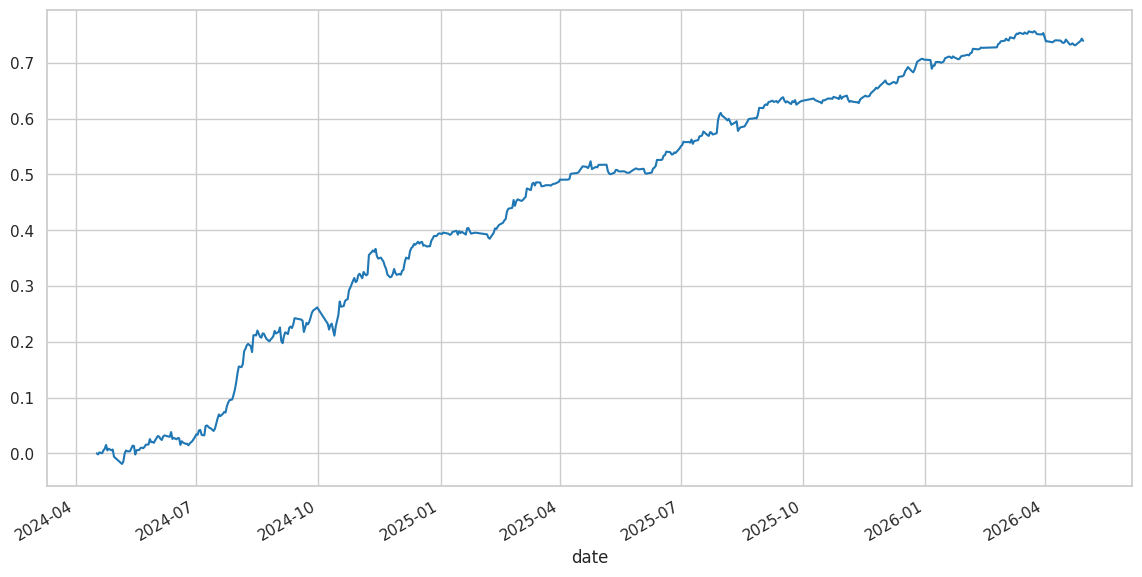

In [28]:
cum_return.plot()

<Axes: >

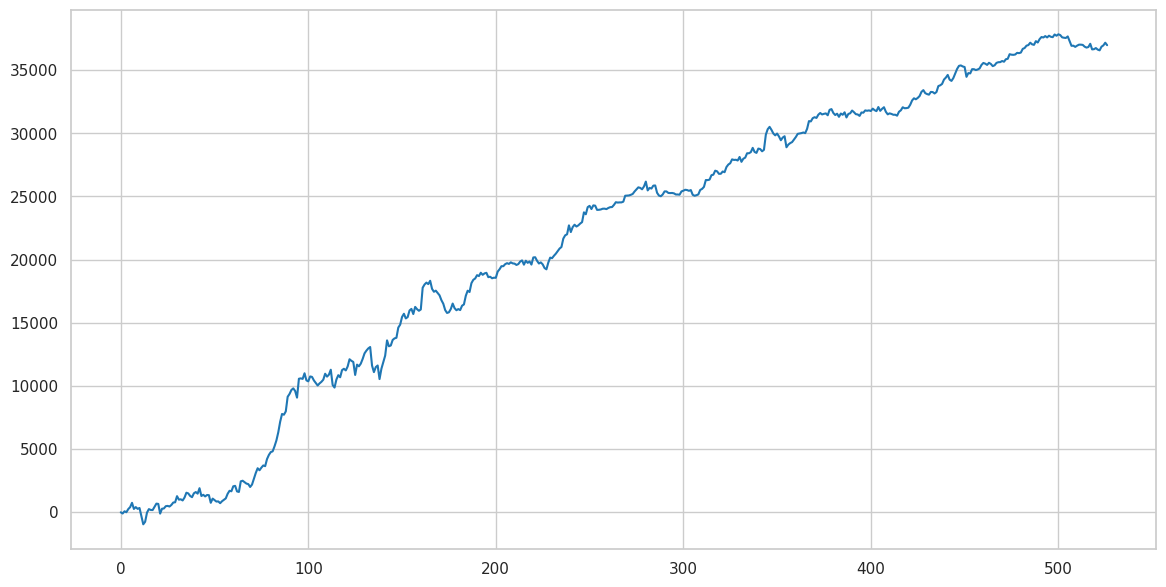

In [29]:
daily_stats['cumulative_pnl'].plot()